# 04. 결과 해석 및 대시보드 방향 정리

## 문화시설 활성화에 대한 운영·이용 현황 성과 분석

이 노트북은 EDA, 통계분석, 머신러닝 모델링 결과를 종합해 **문화시설 활성화 요인**을 해석하는 단계이다.

앞선 노트북의 역할은 다음과 같다.

| 노트북 | 역할 |
|---|---|
| `01_modeling_preparation.ipynb` | 목적변수, 입력 변수, 제외 변수, 결측 처리 방향 정리 |
| `02_statistical_analysis.ipynb` | 시설 유형·지역·운영/시설 변수와 관람객 수의 통계적 관계 검정 |
| `03_machine_learning_modeling.ipynb` | 변수 세트별 예측 성능 비교와 변수 중요도 확인 |
| `04_result_interpretation.ipynb` | 분석 결과를 최종 인사이트와 대시보드 기획으로 연결 |

분석의 핵심 질문은 다음과 같다.

1. 관람객 수는 어떤 시설 특성과 관련이 있는가?
2. 통계적으로 유의한 차이와 실제 해석 가능한 차이는 무엇인가?
3. 머신러닝 모델에서 관람객 수 예측에 중요한 변수는 무엇인가?
4. 태블로 대시보드에서는 어떤 지표와 화면으로 보여줄 수 있는가?

## 1. 라이브러리 및 결과 파일 불러오기

이 노트북은 앞선 노트북에서 저장한 결과 CSV를 사용한다.

기본 경로는 다음과 같이 가정한다.

```text
outputs/statistics/
outputs/ml/
data/processed/facility_eda_preprocessed.csv
```

단, 파일이 현재 노트북과 같은 폴더에 있어도 읽을 수 있도록 경로 탐색 함수를 함께 사용한다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

ROOT = Path(".")
STAT_DIR = ROOT / "outputs" / "statistics"
ML_DIR = ROOT / "outputs" / "ml"
DATA_DIR = ROOT / "data" / "processed"

SEARCH_DIRS = [ROOT, STAT_DIR, ML_DIR, DATA_DIR, Path("/mnt/data")]


def find_existing_file(candidates):
    """여러 후보 파일명과 탐색 폴더 중 실제 존재하는 파일 경로를 반환"""
    for candidate in candidates:
        candidate_path = Path(candidate)
        if candidate_path.exists():
            return candidate_path
        for directory in SEARCH_DIRS:
            path = directory / candidate
            if path.exists():
                return path
    return None


def read_result(candidates, required=True):
    path = find_existing_file(candidates)
    if path is None:
        if required:
            raise FileNotFoundError(f"파일을 찾지 못했습니다: {candidates}")
        return None
    df = pd.read_csv(path)
    print(f"로드 완료: {path} | shape={df.shape}")
    return df

In [2]:
# 통계분석 결과
facility_type_test = read_result(["facility_type_test_result.csv", "facility_type_test.csv"])
type_summary = read_result(["type_summary.csv"])
province_summary = read_result(["province_summary.csv"])
province_diff = read_result(["province_difference_test_result.csv", "province_difference_test.csv"])
province_pairwise = read_result(["province_pairwise_mannwhitney_holm.csv"], required=False)
region_group_diff = read_result(["region_group_difference_test_result.csv", "region_group_difference_test.csv"])
correlation_results = read_result(["correlation_results.csv"])
by_type_correlation = read_result(["by_type_correlation_results.csv"], required=False)
service_test = read_result(["service_test_results.csv"])
missingness_test = read_result(["missingness_test_results.csv", "missing_group_test_results.csv"])
ols_basic = read_result(["ols_basic_coefficients.csv"])

# 머신러닝 결과
model_performance = read_result(["model_performance.csv"])
permutation_importance = read_result(["best_model_permutation_importance.csv"])
best_predictions = read_result(["best_model_predictions.csv"])
residual_by_type = read_result(["residual_by_facility_type.csv"])
residual_by_region = read_result(["residual_by_region.csv"])

# 원본 전처리 데이터는 선택적으로 사용
facility_df = read_result(["facility_eda_preprocessed.csv"], required=False)

로드 완료: outputs\statistics\facility_type_test_result.csv | shape=(1, 14)
로드 완료: outputs\statistics\type_summary.csv | shape=(2, 7)
로드 완료: outputs\statistics\province_summary.csv | shape=(20, 7)
로드 완료: outputs\statistics\province_difference_test_result.csv | shape=(1, 11)
로드 완료: outputs\statistics\province_pairwise_mannwhitney_holm.csv | shape=(190, 12)
로드 완료: outputs\statistics\region_group_difference_test_result.csv | shape=(1, 11)
로드 완료: outputs\statistics\correlation_results.csv | shape=(15, 9)
로드 완료: outputs\statistics\by_type_correlation_results.csv | shape=(30, 6)
로드 완료: outputs\statistics\service_test_results.csv | shape=(2, 12)
로드 완료: outputs\statistics\missingness_test_results.csv | shape=(12, 12)
로드 완료: outputs\statistics\ols_basic_coefficients.csv | shape=(12, 8)
로드 완료: outputs\ml\model_performance.csv | shape=(21, 9)
로드 완료: outputs\ml\best_model_permutation_importance.csv | shape=(19, 3)
로드 완료: outputs\ml\best_model_predictions.csv | shape=(228, 13)
로드 완료: outputs\ml\residua

## 2. 전체 결과 요약

먼저 앞선 분석 결과에서 핵심 수치를 한 번에 확인한다.

In [3]:
# 최적 모델
best_model = model_performance.sort_values(["RMSE_log", "MAE_log"]).iloc[0]

# 기준 모델 대비 개선 정도
baseline = model_performance[model_performance["model"].eq("Dummy_mean")].iloc[0]
rmse_improvement = (baseline["RMSE_log"] - best_model["RMSE_log"]) / baseline["RMSE_log"] * 100
r2_gain = best_model["R2_log"] - baseline["R2_log"]

# 주요 통계 결과
facility_test_row = facility_type_test.iloc[0]
province_diff_row = province_diff.iloc[0]
region_diff_row = region_group_diff.iloc[0]

overall_summary = pd.DataFrame([
    {
        "구분": "최적 머신러닝 모델",
        "핵심 결과": f"{best_model['feature_set']} 변수 세트 + {best_model['model']}",
        "주요 수치": f"RMSE_log={best_model['RMSE_log']:.3f}, R²_log={best_model['R2_log']:.3f}",
        "해석": "기본 변수보다 인력 포함 변수 세트에서 예측 성능이 가장 높게 나타남"
    },
    {
        "구분": "기준 모델 대비 개선",
        "핵심 결과": "Dummy 평균 예측 모델 대비 성능 개선",
        "주요 수치": f"RMSE_log 약 {rmse_improvement:.1f}% 감소",
        "해석": "운영·시설·인력 변수들이 관람객 수 예측에 설명력을 제공"
    },
    {
        "구분": "시설 유형 차이",
        "핵심 결과": facility_test_row["comparison"],
        "주요 수치": f"Mann-Whitney p={facility_test_row['mannwhitney_p']:.4g}, Cohen's d={facility_test_row['cohens_d']:.3f}",
        "해석": "통계적으로 유의하지만 효과크기는 작아 단독 핵심 요인으로 보기는 어려움"
    },
    {
        "구분": "시도별 차이",
        "핵심 결과": f"{int(province_diff_row['n_groups'])}개 시도 집단 차이 유의",
        "주요 수치": f"Kruskal p={province_diff_row['kruskal_p']:.4g}, epsilon²={province_diff_row['epsilon_squared']:.3f}",
        "해석": "지역별 관람객 수 차이가 확인되며, 특히 제주권이 높게 나타남"
    },
    {
        "구분": "권역별 차이",
        "핵심 결과": f"{int(region_diff_row['n_groups'])}개 권역 집단 차이 유의",
        "주요 수치": f"Kruskal p={region_diff_row['kruskal_p']:.4g}, epsilon²={region_diff_row['epsilon_squared']:.3f}",
        "해석": "권역 단위에서도 관람객 수 차이가 확인됨"
    },
])

display(overall_summary)

,구분,핵심 결과,주요 수치,해석
0,최적 머신러닝 모델,staff 변수 세트 + Lasso,"RMSE_log=1.303, R²_log=0.500",기본 변수보다 인력 포함 변수 세트에서 예측 성능이 가장 높게 나타남
1,기준 모델 대비 개선,Dummy 평균 예측 모델 대비 성능 개선,RMSE_log 약 29.3% 감소,운영·시설·인력 변수들이 관람객 수 예측에 설명력을 제공
2,시설 유형 차이,미술관 vs 박물관,"Mann-Whitney p=0.004921, Cohen's d=-0.169",통계적으로 유의하지만 효과크기는 작아 단독 핵심 요인으로 보기는 어려움
3,시도별 차이,20개 시도 집단 차이 유의,"Kruskal p=1.692e-05, epsilon²=0.033","지역별 관람객 수 차이가 확인되며, 특히 제주권이 높게 나타남"
4,권역별 차이,6개 권역 집단 차이 유의,"Kruskal p=1.633e-07, epsilon²=0.031",권역 단위에서도 관람객 수 차이가 확인됨


### 전체 해석

이번 분석에서 관람객 수는 특정 단일 변수만으로 설명되기보다는 **운영일수, 시설 규모, 교육시설면적, 프로그램 수, 인력 정보, 지역 특성, 서비스 제공 여부**가 복합적으로 관련된 것으로 나타났다.

머신러닝 결과에서는 `staff` 변수 세트의 `Lasso` 모델이 가장 좋은 성능을 보였고, 로그 관람객 수 기준 `RMSE_log=1.303`, `R²_log=0.500` 수준을 보였다. 이는 평균만 예측하는 기준 모델보다 뚜렷하게 개선된 결과이며, 문화시설의 운영·시설·인력 변수가 관람객 수 예측에 일정 수준의 설명력을 갖는다는 점을 보여준다.

다만 인력 변수는 결측률이 높으므로, 최종 해석에서는 **직접적인 원인**이라기보다 **예측 성능을 보완하는 참고 변수**로 다루는 것이 적절하다.

## 3. 시설 유형별 관람객 수 차이 해석

박물관과 미술관은 EDA 단계에서 운영연수, 시설 규모, 프로그램 수, 인력 변수 등에서 차이를 보였다. 여기서는 관람객 수 차이가 통계적으로도 확인되는지 살펴본다.

In [4]:
display(type_summary)
display(facility_type_test)

,facility_type,n,mean_log_viewers,median_log_viewers,std_log_viewers,mean_viewers,median_viewers
0,박물관,856,9.8804,9.9690,1.8616,"86,859.3762","21,353.0000"
1,미술관,281,9.5718,9.5031,1.6981,"60,374.8256","13,400.0000"


,comparison,n_1,n_2,mean_1,mean_2,median_1,median_2,welch_t,welch_p,welch_sig,mannwhitney_u,mannwhitney_p,mannwhitney_sig,cohens_d
0,미술관 vs 박물관,281,856,9.5718,9.8804,9.5031,9.9690,-2.5795,0.0102,*,"106,836.5000",0.0049,**,-0.1693


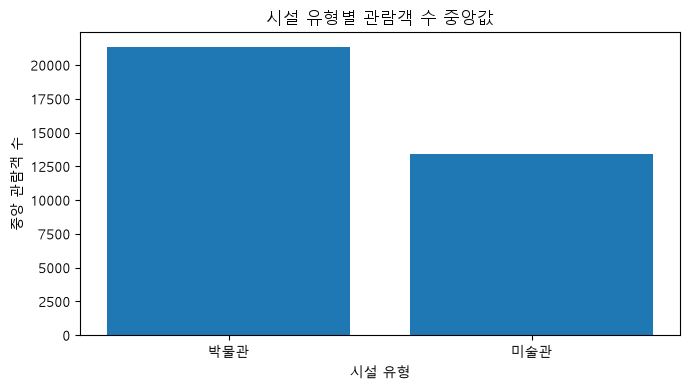

In [5]:
# 시설 유형별 중앙 관람객 수 시각화
plot_df = type_summary.sort_values("median_viewers", ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(plot_df["facility_type"], plot_df["median_viewers"])
plt.title("시설 유형별 관람객 수 중앙값")
plt.xlabel("시설 유형")
plt.ylabel("중앙 관람객 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 해석

시설 유형별 분석 결과, 박물관의 관람객 수 중앙값은 **21,353명**, 미술관의 관람객 수 중앙값은 **13,400명**으로 나타났다. Mann-Whitney U 검정에서도 p-value가 **0.0049**로 나타나, 박물관과 미술관의 로그 관람객 수 분포에는 통계적으로 유의한 차이가 확인되었다.

하지만 Cohen's d는 **-0.169** 수준으로 효과크기가 작다. 따라서 “박물관이라서 관람객 수가 많다”라고 단순 해석하기보다는, 박물관과 미술관이 가진 **시설 규모, 개관일수, 프로그램 수, 지역 분포, 인력 구조 차이**가 함께 영향을 미쳤을 가능성을 고려해야 한다.

즉, 시설 유형은 활성화 수준을 구분하는 참고 기준이지만, 단독으로 문화시설 활성화를 설명하는 핵심 요인으로 보기는 어렵다.

## 4. 지역별 관람객 수 차이 해석

EDA에서 경기와 서울은 시설 수가 많았지만, 관람객 수 중앙값은 제주권에서 높게 나타났다. 통계분석 결과에서도 지역 차이가 확인되는지 살펴본다.

In [6]:
# 시도별 요약 상위 10개
province_top = province_summary.sort_values("median_viewers", ascending=False).head(10)
display(province_top)

display(province_diff)
display(region_group_diff)

if province_pairwise is not None:
    significant_pairs = province_pairwise[province_pairwise["reject_0.05"] == True].copy()
    display(significant_pairs.head(10))

,CTPRVN_NM,n,mean_log_viewers,median_log_viewers,std_log_viewers,mean_viewers,median_viewers
0,제주특별자치도,57,11.0926,11.3459,1.4623,"147,073.1053","84,617.0000"
1,제주,20,10.4483,10.5681,1.0645,"55,629.5500","39,635.5000"
2,전북특별자치도,38,10.1505,10.4717,1.9673,"87,471.1579","35,303.0000"
3,울산,11,10.7659,10.4528,0.9980,"72,789.6364","34,640.0000"
4,인천,36,9.7535,10.2819,1.8502,"57,082.5278","29,320.5000"
5,경북,79,9.8693,10.1309,1.7727,"66,986.2152","25,106.0000"
6,경남,82,10.0005,10.1024,1.4788,"56,053.9024","24,434.0000"
7,경기,184,9.6081,9.9093,1.7832,"53,165.5054","20,115.0000"
8,충남,70,9.9009,9.8483,1.9939,"140,097.6571","18,929.5000"
9,강원특별자치도,94,9.7285,9.7703,1.6863,"55,520.5745","17,531.5000"


,group_col,n_groups,n_obs,anova_F,anova_p,anova_sig,eta_squared,kruskal_H,kruskal_p,kruskal_sig,epsilon_squared
0,CTPRVN_NM,20,1137,2.6410,0.0002,***,0.0430,55.8980,0.0000,***,0.0330


,group_col,n_groups,n_obs,anova_F,anova_p,anova_sig,eta_squared,kruskal_H,kruskal_p,kruskal_sig,epsilon_squared
0,REGION_GROUP,6,1137,7.1808,0.0000,***,0.0308,39.8074,0.0000,***,0.0308


,group_1,group_2,n_1,n_2,median_1,median_2,median_diff_1_minus_2,u_statistic,p_value,p_adj_holm,reject_0.05,sig
0,경기,제주특별자치도,184,57,9.9093,11.3459,-1.4366,"2,711.0000",0.0000,0.0000,True,***
1,전남,제주특별자치도,101,57,9.6068,11.3459,-1.7391,"1,369.0000",0.0000,0.0000,True,***
2,강원특별자치도,제주특별자치도,94,57,9.7703,11.3459,-1.5756,"1,413.0000",0.0000,0.0002,True,***
3,제주특별자치도,충북,57,48,11.3459,9.3831,1.9628,"2,117.5000",0.0000,0.0003,True,***
4,서울,제주특별자치도,172,57,9.6058,11.3459,-1.7401,"2,963.0000",0.0000,0.0014,True,**
5,경남,제주특별자치도,82,57,10.1024,11.3459,-1.2435,"1,335.5000",0.0000,0.0034,True,**
6,광주,제주특별자치도,26,57,9.1005,11.3459,-2.2454,310.0000,0.0000,0.0044,True,**
7,경북,제주특별자치도,79,57,10.1309,11.3459,-1.2150,"1,316.5000",0.0000,0.0069,True,**
8,전북,제주특별자치도,20,57,9.4164,11.3459,-1.9296,219.0000,0.0000,0.0085,True,**
9,제주특별자치도,충남,57,70,11.3459,9.8483,1.4976,"2,817.0000",0.0001,0.0124,True,*


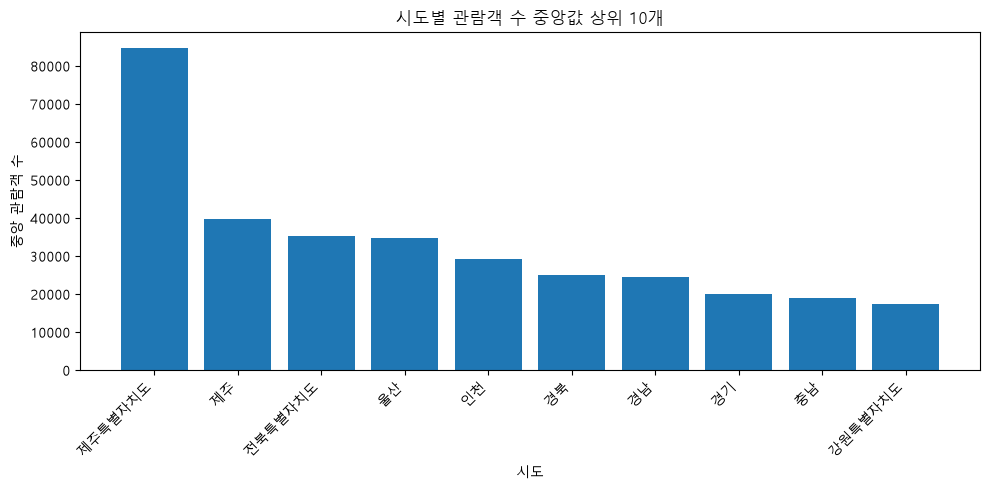

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(province_top["CTPRVN_NM"], province_top["median_viewers"])
plt.title("시도별 관람객 수 중앙값 상위 10개")
plt.xlabel("시도")
plt.ylabel("중앙 관람객 수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# 지역명 표준화 필요 여부 점검
if facility_df is not None and "CTPRVN_NM" in facility_df.columns:
    province_names = sorted(facility_df["CTPRVN_NM"].dropna().unique())
    print("시도명 목록:")
    print(province_names)

    suspicious_pairs = [
        ("제주", "제주특별자치도"),
        ("강원", "강원특별자치도"),
        ("전북", "전북특별자치도"),
    ]

    print()
    print("표준화 검토가 필요한 지역명:")
    for a, b in suspicious_pairs:
        if a in province_names and b in province_names:
            print(f"- {a} / {b}")

시도명 목록:
['강원', '강원특별자치도', '경기', '경남', '경북', '광주', '대구', '대전', '부산', '서울', '세종특별자치시', '울산', '인천', '전남', '전북', '전북특별자치도', '제주', '제주특별자치도', '충남', '충북']

표준화 검토가 필요한 지역명:
- 제주 / 제주특별자치도
- 강원 / 강원특별자치도
- 전북 / 전북특별자치도


### 해석

시도별 분석에서는 로그 관람객 수 차이가 통계적으로 유의하게 나타났다. Kruskal-Wallis 검정 p-value는 **0.000017** 수준이며, 권역 단위에서도 p-value가 **1.63e-07**로 나타나 지역별 차이가 일관되게 확인되었다.

시도별 관람객 수 중앙값 기준으로는 `제주특별자치도`가 **84,617명**으로 가장 높게 나타났다. 이는 EDA에서 확인했던 “시설 수는 경기·서울에 많지만, 관람객 수 중앙값은 제주가 높다”는 결과와 연결된다.

다만 결과 파일에서는 `제주`와 `제주특별자치도`, `강원`과 `강원특별자치도`, `전북`과 `전북특별자치도`처럼 시도명이 분리될 가능성이 있다. 최종 태블로 대시보드에서는 지역명을 표준화한 뒤 시각화하는 것이 좋다.

지역 차이는 단순히 행정구역 효과만을 의미하지 않는다. 관광 수요, 대표 시설 존재 여부, 접근성, 지역 문화정책, 대형 시설 집중 여부 등이 복합적으로 반영된 결과로 해석해야 한다.

## 5. 주요 수치형 변수와 관람객 수의 관계

상관분석은 단일 변수와 관람객 수 간의 방향성과 강도를 확인하는 데 사용한다. 여기서는 Spearman 상관계수를 중심으로 해석한다. Spearman 상관계수는 이상치와 비선형 단조 관계에 상대적으로 안정적이다.

In [9]:
# Spearman 상관계수 기준 상위 변수
corr_top = correlation_results.sort_values("spearman_rho", ascending=False).copy()
display(corr_top[["variable", "n", "missing_rate", "spearman_rho", "spearman_p", "spearman_sig"]].head(15))

,variable,n,missing_rate,spearman_rho,spearman_p,spearman_sig
0,GNRL_GVRNM_EMP_CO,288,0.7467,0.6151,0.0000,***
1,QUALF_HOLD_CO,423,0.6280,0.5113,0.0000,***
2,OPNNG_DAY_CO,1136,0.0009,0.4870,0.0000,***
3,LOG1P_LND_AR_VALUE,1127,0.0088,0.4746,0.0000,***
4,CNTRCT_EMP_CO,170,0.8505,0.3690,0.0000,***
5,LOG1P_EDC_FCLTY_AR_VALUE,834,0.2665,0.3606,0.0000,***
6,PUBLIC_VLNTER_CO,183,0.8391,0.3247,0.0000,***
7,LOG1P_DATA_SPCE_AR_VALUE,657,0.4222,0.2647,0.0000,***
8,PRFSN_CO,205,0.8197,0.2461,0.0004,***
9,LOG1P_TOT_PROGRM_CO,895,0.2128,0.2440,0.0000,***


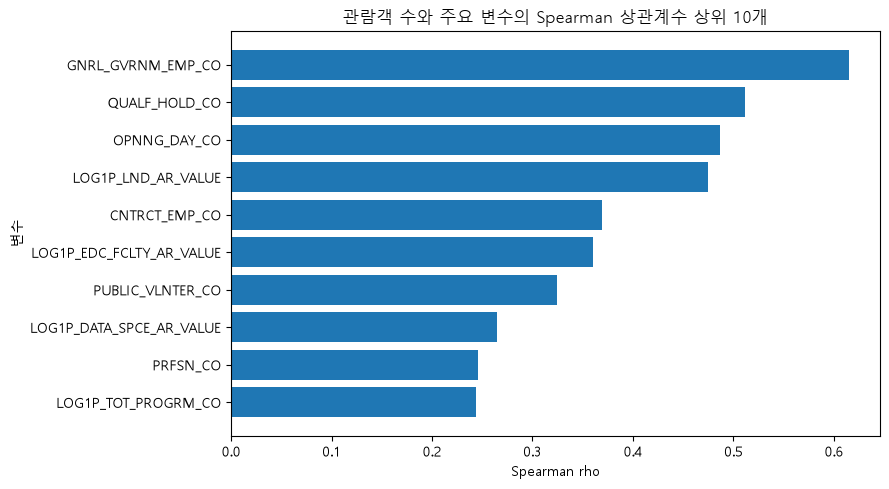

In [10]:
plot_corr = corr_top.head(10).sort_values("spearman_rho")

plt.figure(figsize=(9, 5))
plt.barh(plot_corr["variable"], plot_corr["spearman_rho"])
plt.title("관람객 수와 주요 변수의 Spearman 상관계수 상위 10개")
plt.xlabel("Spearman rho")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

### 해석

상관분석 결과, `OPNNG_DAY_CO`, `LOG1P_LND_AR_VALUE`, `LOG1P_EDC_FCLTY_AR_VALUE` 등 운영일수와 시설 규모 관련 변수가 로그 관람객 수와 비교적 뚜렷한 양의 관계를 보였다.

특히 `OPNNG_DAY_CO`의 Spearman 상관계수는 **0.487**, `LOG1P_LND_AR_VALUE`는 **0.475**로 나타났다. 이는 개관일수가 많고 시설 규모가 클수록 관람객 수가 높은 경향이 있음을 의미한다.

`LOG1P_TOT_PROGRM_CO`는 양의 상관관계가 확인되지만 Spearman 상관계수는 **0.244** 수준으로 상대적으로 약하다. 따라서 프로그램 수는 관람객 수와 관련이 있지만, 단순히 프로그램 수를 늘리는 것만으로 활성화가 설명된다고 보기는 어렵다.

인력 관련 변수 중 일부는 높은 상관계수를 보였지만 결측률이 높다. 예를 들어 `GNRL_GVRNM_EMP_CO`는 Spearman 상관계수가 **0.615**로 높지만 결측률이 약 **74.7%**이다. 따라서 인력 변수는 중요한 가능성을 가진 변수이지만, 해석 시 결측 편향을 반드시 함께 고려해야 한다.

## 6. 서비스 제공 여부와 관람객 수

모바일 제공 여부와 음성 제공 여부는 접근성·편의성 지표로 볼 수 있다. 다만 서비스 제공 자체가 관람객 수를 직접 증가시켰다고 해석하기보다는, 대형 시설일수록 관련 서비스를 갖추고 있을 가능성도 함께 고려해야 한다.

In [11]:
display(service_test)

,variable,group_1,group_2,n_1,n_2,median_1,median_2,welch_p,mannwhitney_p,cohens_d,welch_sig,mannwhitney_sig
0,MOBILE_PROVD_AT,O,X,251,880,11.0981,9.5799,0.0000,0.0000,0.8142,***,***
1,SOUND_PROVD_AT,O,X,164,967,10.9688,9.6159,0.0000,0.0000,0.7452,***,***


In [12]:
service_plot = service_test.copy()
service_plot["median_diff_O_minus_X"] = service_plot["median_1"] - service_plot["median_2"]

display(service_plot[["variable", "n_1", "n_2", "median_1", "median_2", "median_diff_O_minus_X", "mannwhitney_p", "cohens_d"]])

,variable,n_1,n_2,median_1,median_2,median_diff_O_minus_X,mannwhitney_p,cohens_d
0,MOBILE_PROVD_AT,251,880,11.0981,9.5799,1.5181,0.0000,0.8142
1,SOUND_PROVD_AT,164,967,10.9688,9.6159,1.3529,0.0000,0.7452


### 해석

모바일 제공 시설과 미제공 시설 간의 로그 관람객 수 차이는 통계적으로 유의하게 나타났다. 모바일 제공 시설의 로그 관람객 수 중앙값은 **11.098**, 미제공 시설은 **9.580**으로 차이가 있었다. 음성 제공 여부도 유사하게, 제공 시설의 중앙값이 **10.969**, 미제공 시설은 **9.616**으로 나타났다.

두 변수 모두 Cohen's d가 0.7 이상으로 나타나 차이의 크기도 비교적 큰 편이다. 다만 이는 서비스 제공 자체의 직접 효과라기보다, 관람객이 많은 대형 시설일수록 모바일·음성 안내 서비스를 갖추고 있을 가능성이 있다.

따라서 대시보드에서는 이 지표를 “활성화 원인”이라기보다 **관람객 규모가 큰 시설의 서비스 제공 특성** 또는 **접근성·안내 서비스 현황**으로 표현하는 것이 적절하다.

## 7. 회귀분석 결과 해석

회귀분석은 여러 요인을 동시에 고려했을 때 어떤 변수가 관람객 수와 관련되는지 확인하는 데 사용한다. 여기서는 `LOG1P_VIEWNG_NMPR_CO`를 종속변수로 한 기본 회귀분석 결과를 해석한다.

In [13]:
display(ols_basic)

sig_ols = ols_basic[ols_basic["sig"].ne("n.s.")].copy()
display(sig_ols)

,term,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],sig
0,Intercept,1.2231,0.4351,2.8110,0.0049,0.3703,2.0759,**
1,C(facility_type)[T.박물관],0.1677,0.1223,1.3712,0.1703,-0.0720,0.4075,n.s.
2,C(REGION_GROUP)[T.경상권],0.4725,0.1743,2.7101,0.0067,0.1308,0.8142,**
3,C(REGION_GROUP)[T.수도권],0.5307,0.1700,3.1217,0.0018,0.1975,0.8640,**
4,C(REGION_GROUP)[T.전라권],0.5825,0.1831,3.1806,0.0015,0.2236,0.9415,**
5,C(REGION_GROUP)[T.제주권],0.7677,0.2552,3.0089,0.0026,0.2676,1.2678,**
6,C(REGION_GROUP)[T.충청권],0.3197,0.2049,1.5604,0.1187,-0.0819,0.7212,n.s.
7,OPERATING_YEARS,0.0019,0.0033,0.5813,0.5611,-0.0045,0.0083,n.s.
8,OPNNG_DAY_CO,0.0103,0.0011,9.6171,0.0000,0.0082,0.0124,***
9,LOG1P_LND_AR_VALUE,0.2612,0.0366,7.1410,0.0000,0.1895,0.3329,***


,term,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],sig
0,Intercept,1.2231,0.4351,2.8110,0.0049,0.3703,2.0759,**
2,C(REGION_GROUP)[T.경상권],0.4725,0.1743,2.7101,0.0067,0.1308,0.8142,**
3,C(REGION_GROUP)[T.수도권],0.5307,0.1700,3.1217,0.0018,0.1975,0.8640,**
4,C(REGION_GROUP)[T.전라권],0.5825,0.1831,3.1806,0.0015,0.2236,0.9415,**
5,C(REGION_GROUP)[T.제주권],0.7677,0.2552,3.0089,0.0026,0.2676,1.2678,**
8,OPNNG_DAY_CO,0.0103,0.0011,9.6171,0.0000,0.0082,0.0124,***
9,LOG1P_LND_AR_VALUE,0.2612,0.0366,7.1410,0.0000,0.1895,0.3329,***
10,LOG1P_EDC_FCLTY_AR_VALUE,0.3946,0.0565,6.9798,0.0000,0.2838,0.5055,***
11,LOG1P_TOT_PROGRM_CO,0.4581,0.0658,6.9630,0.0000,0.3291,0.5870,***


### 해석

기본 회귀분석에서는 `OPNNG_DAY_CO`, `LOG1P_LND_AR_VALUE`, `LOG1P_EDC_FCLTY_AR_VALUE`, `LOG1P_TOT_PROGRM_CO`가 유의한 양의 계수를 보였다.

이는 다른 요인을 함께 고려하더라도 다음 요인이 관람객 수와 관련됨을 의미한다.

| 요인 | 해석 |
|---|---|
| 개관일수 | 연간 운영일수가 많을수록 관람객 수가 높은 경향 |
| 토지면적 | 시설 규모가 클수록 관람객 수가 높은 경향 |
| 교육시설면적 | 교육·체험 공간이 클수록 관람객 수가 높은 경향 |
| 프로그램 수 | 프로그램 운영 규모가 클수록 관람객 수가 높은 경향 |
| 권역 | 일부 권역은 기준 권역 대비 관람객 수가 높은 경향 |

반면 시설 유형 자체는 회귀모형에서 유의하지 않았다. 이는 박물관과 미술관의 차이가 존재하더라도, 그 차이의 상당 부분이 규모·운영일수·프로그램·지역 요인으로 설명될 수 있음을 시사한다.

## 8. 머신러닝 모델 성능 비교

머신러닝 단계에서는 `basic`, `extended`, `staff` 변수 세트를 비교했다. 여기서 핵심은 단순히 최고 성능 모델 하나를 찾는 것이 아니라, 어떤 변수 세트가 관람객 수 예측에 추가 설명력을 제공하는지 확인하는 것이다.

In [14]:
model_perf_sorted = model_performance.sort_values(["RMSE_log", "MAE_log"]).reset_index(drop=True)
display(model_perf_sorted)

# 변수 세트별 최고 성능
best_by_set = (
    model_perf_sorted
    .sort_values(["feature_set", "RMSE_log"])
    .groupby("feature_set", as_index=False)
    .first()
    .sort_values("RMSE_log")
)
display(best_by_set)

,feature_set,model,n_features_raw,MAE_log,RMSE_log,R2_log,MAE_original,RMSE_original,MedianAE_original
0,staff,Lasso,19,1.0532,1.3033,0.4995,"58,036.4039","216,857.0767","13,404.7871"
1,staff,GradientBoosting,19,1.0305,1.3043,0.4988,"53,520.7083","208,129.3893","14,094.3590"
2,staff,Ridge,19,1.0548,1.3051,0.4981,"58,056.6662","217,002.4412","13,358.6746"
3,staff,RandomForest,19,1.0161,1.3068,0.4968,"52,937.2086","208,619.7910","13,055.1903"
4,staff,LinearRegression,19,1.0573,1.3074,0.4964,"58,202.0026","217,017.8698","13,609.7213"
5,extended,ExtraTrees,12,1.0675,1.3217,0.4853,"55,580.1866","209,990.0388","13,655.6829"
6,extended,Lasso,12,1.0740,1.3226,0.4845,"57,756.0053","212,247.0212","15,406.9418"
7,extended,Ridge,12,1.0755,1.3237,0.4837,"57,782.3965","212,359.4829","15,490.3260"
8,extended,LinearRegression,12,1.0769,1.3253,0.4824,"57,870.5812","212,399.9253","15,593.7306"
9,extended,GradientBoosting,12,1.0534,1.3286,0.4799,"54,718.1192","208,344.4953","14,419.9484"


,feature_set,model,n_features_raw,MAE_log,RMSE_log,R2_log,MAE_original,RMSE_original,MedianAE_original
2,staff,Lasso,19,1.0532,1.3033,0.4995,"58,036.4039","216,857.0767","13,404.7871"
1,extended,ExtraTrees,12,1.0675,1.3217,0.4853,"55,580.1866","209,990.0388","13,655.6829"
0,basic,GradientBoosting,9,1.0801,1.3662,0.4500,"57,782.3749","212,187.6741","14,284.8319"


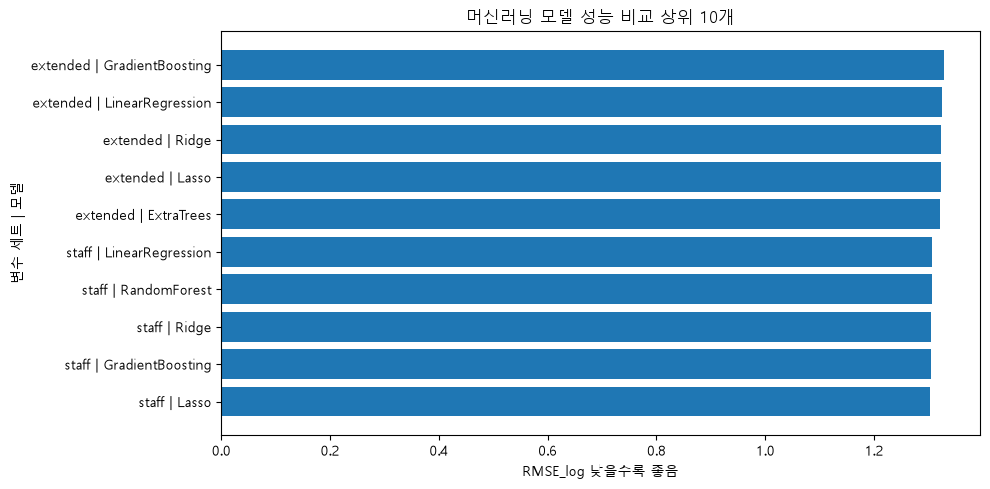

In [15]:
plot_model = model_perf_sorted.head(10).copy()
plot_model["label"] = plot_model["feature_set"] + " | " + plot_model["model"]
plot_model = plot_model.sort_values("RMSE_log", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_model["label"], plot_model["RMSE_log"])
plt.title("머신러닝 모델 성능 비교 상위 10개")
plt.xlabel("RMSE_log 낮을수록 좋음")
plt.ylabel("변수 세트 | 모델")
plt.tight_layout()
plt.show()

### 해석

최적 모델은 `staff` 변수 세트의 `Lasso` 모델로 나타났다. 성능은 `RMSE_log=1.303`, `R²_log=0.500` 수준이다.

변수 세트별로 보면 `basic`보다 `extended`, `extended`보다 `staff` 변수 세트가 대체로 더 좋은 성능을 보였다. 이는 기본 운영·시설 변수에 더해 자료 규모와 인력 관련 변수가 관람객 수 예측에 추가 정보를 제공할 가능성을 보여준다.

다만 원 단위 기준 MAE는 약 **58,036명**이고 RMSE는 약 **216,857명**으로 매우 크다. 이는 관람객 수 분포가 오른쪽 꼬리가 길고 대형 시설의 오차가 크게 작용하기 때문이다. 따라서 최종 성능 평가는 원 단위 평균 오차보다는 로그 기준 성능과 중앙 절대 오차를 함께 보는 것이 적절하다.

## 9. 머신러닝 변수 중요도 해석

최적 모델에 대해 permutation importance를 확인한다. 이 값은 특정 변수를 섞었을 때 예측 성능이 얼마나 떨어지는지를 기준으로 계산된다.

In [16]:
display(permutation_importance)

,feature,importance_mean,importance_std
0,OPNNG_DAY_CO,0.1796,0.0159
1,LOG1P_NMPR_CO,0.1142,0.0299
2,LOG1P_LND_AR_VALUE,0.0791,0.0162
3,ARTGR_EMP_CO,0.0577,0.0103
4,facility_type,0.0377,0.0084
5,LOG1P_TOT_PROGRM_CO,0.0363,0.0102
6,MOBILE_PROVD_AT,0.0287,0.0106
7,LOG1P_EDC_FCLTY_AR_VALUE,0.0185,0.0045
8,PRVATE_VLNTER_CO,0.0184,0.0065
9,LOG1P_DATA_CO,0.0184,0.0077


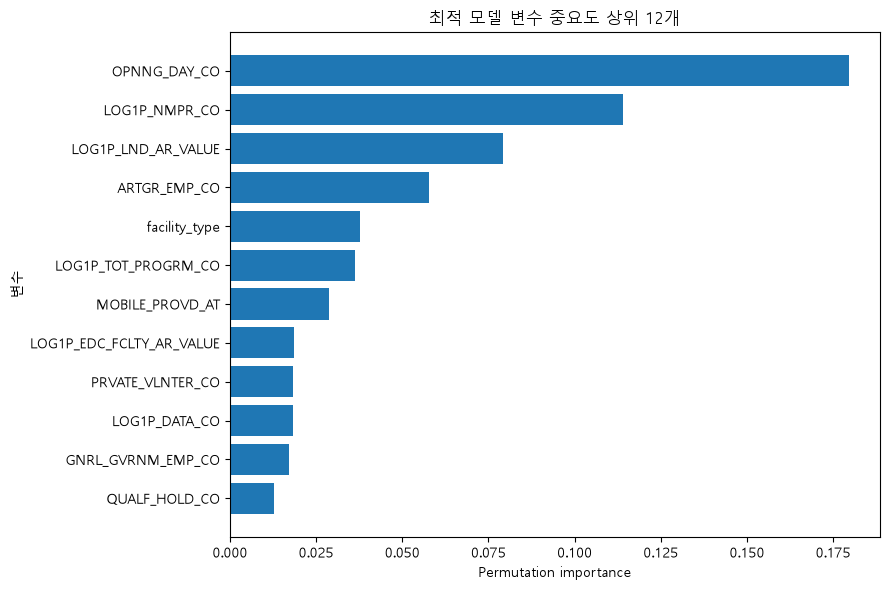

In [17]:
plot_importance = permutation_importance.head(12).sort_values("importance_mean")

plt.figure(figsize=(9, 6))
plt.barh(plot_importance["feature"], plot_importance["importance_mean"])
plt.title("최적 모델 변수 중요도 상위 12개")
plt.xlabel("Permutation importance")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

### 해석

최적 모델의 변수 중요도 상위 변수는 다음과 같다.

| 순위 | 변수 | 해석 |
|---|---|---|
| 1 | `OPNNG_DAY_CO` | 연간 개관일수 |
| 2 | `LOG1P_NMPR_CO` | 전체 인원 수 |
| 3 | `LOG1P_LND_AR_VALUE` | 토지면적 |
| 4 | `ARTGR_EMP_CO` | 학예 인력 수 |
| 5 | `facility_type` | 박물관/미술관 유형 |
| 6 | `LOG1P_TOT_PROGRM_CO` | 프로그램 수 |

통계분석과 머신러닝 결과를 함께 보면, **개관일수와 시설 규모**는 가장 일관적으로 중요한 요인이다. 인력 변수는 머신러닝에서 중요하게 나타났지만 결측률이 높기 때문에 보조 해석 변수로 다루는 것이 적절하다.

또한 프로그램 수는 상관분석에서는 약한 양의 관계였지만, 회귀분석과 머신러닝에서는 일정 수준의 설명력을 보였다. 즉, 프로그램 수는 단독 관계만 보면 강하지 않지만, 시설 규모·지역·운영일수와 함께 고려할 때 관람객 수 예측에 기여할 수 있다.

## 10. 예측 오차 해석

모델 예측 결과는 “조건 대비 관람객 수가 높은 시설”과 “조건 대비 관람객 수가 낮은 시설”을 탐색하는 데 활용할 수 있다.

여기서 `error_log = actual_log - pred_log`로 해석한다.

| error_log | 해석 |
|---|---|
| 양수 | 실제 관람객 수가 예측보다 높음, 조건 대비 성과가 좋은 시설 |
| 음수 | 실제 관람객 수가 예측보다 낮음, 조건 대비 활성화 점검이 필요한 시설 |

In [18]:
pred_eval = best_predictions.copy()

pred_eval["performance_group"] = np.select(
    [pred_eval["error_log"] >= 1, pred_eval["error_log"] <= -1],
    ["예상 대비 높음", "예상 대비 낮음"],
    default="예상 범위"
)

performance_summary = (
    pred_eval
    .groupby("performance_group")
    .agg(
        n=("FCLTY_NM", "count"),
        median_actual_viewers=("actual_viewers", "median"),
        median_pred_viewers=("pred_viewers", "median"),
        mean_abs_error_log=("abs_error_log", "mean"),
    )
    .reset_index()
)

display(performance_summary)

# 예상 대비 높은 시설 상위
higher_than_expected = pred_eval.sort_values("error_log", ascending=False).head(10)
display(higher_than_expected[["FCLTY_NM", "facility_type", "CTPRVN_NM", "REGION_GROUP", "actual_viewers", "pred_viewers", "error_log", "performance_group"]])

# 예상 대비 낮은 시설 상위
lower_than_expected = pred_eval.sort_values("error_log", ascending=True).head(10)
display(lower_than_expected[["FCLTY_NM", "facility_type", "CTPRVN_NM", "REGION_GROUP", "actual_viewers", "pred_viewers", "error_log", "performance_group"]])

,performance_group,n,median_actual_viewers,median_pred_viewers,mean_abs_error_log
0,예상 대비 낮음,49,"2,242.0000","13,551.4319",1.6932
1,예상 대비 높음,54,"97,073.0000","14,541.0934",1.7471
2,예상 범위,125,"21,592.0000","17,733.5906",0.5026


,FCLTY_NM,facility_type,CTPRVN_NM,REGION_GROUP,actual_viewers,pred_viewers,error_log,performance_group
147,백제군사박물관,박물관,충남,충청권,"2,917,684.0000","61,580.6842",3.8582,예상 대비 높음
168,목포근대역사관2관,박물관,전남,전라권,"226,015.0000","5,885.1841",3.6480,예상 대비 높음
34,불교천태중앙박물관,박물관,충북,충청권,"100,605.0000","6,586.6856",2.7260,예상 대비 높음
178,고성수석전시관,박물관,경남,경상권,"238,438.0000","18,478.8164",2.5574,예상 대비 높음
171,제천유물전시관,박물관,충북,충청권,"135,757.0000","10,583.8470",2.5515,예상 대비 높음
93,짜장면박물관,박물관,인천,수도권,"161,880.0000","12,884.0875",2.5308,예상 대비 높음
109,솔향공원 소나무전시관,박물관,충북,충청권,"82,450.0000","6,954.4574",2.4727,예상 대비 높음
23,어진박물관,박물관,전북특별자치도,전라권,"81,132.0000","7,063.2887",2.4410,예상 대비 높음
162,대구문화예술회관 미술관,미술관,대구,경상권,"250,636.0000","21,970.7009",2.4343,예상 대비 높음
98,불국사박물관,박물관,경북,경상권,"73,000.0000","6,576.4332",2.4068,예상 대비 높음


,FCLTY_NM,facility_type,CTPRVN_NM,REGION_GROUP,actual_viewers,pred_viewers,error_log,performance_group
7,경주대학교박물관,박물관,경북,경상권,90.0000,"2,681.2604",-3.3836,예상 대비 낮음
150,포마자동차디자인미술관,미술관,경기,수도권,577.0000,"13,459.6169",-3.1479,예상 대비 낮음
117,죽포미술관,미술관,경기,수도권,550.0000,"12,653.2380",-3.1340,예상 대비 낮음
152,학명미술관,미술관,전남,전라권,711.0000,"12,746.4364",-2.8850,예상 대비 낮음
60,신평면 생활사박물관,박물관,전북특별자치도,전라권,200.0000,"2,753.5300",-2.6177,예상 대비 낮음
226,C ART MUSEUM,미술관,경기,수도권,"1,500.0000","19,474.5118",-2.5630,예상 대비 낮음
11,배재대학교 박물관,박물관,대전,충청권,389.0000,"4,231.6629",-2.3844,예상 대비 낮음
149,내설악백공미술관,미술관,강원,강원권,"1,000.0000","9,180.9179",-2.2162,예상 대비 낮음
27,결성농요농사박물관,박물관,충남,충청권,"1,000.0000","9,028.8496",-2.1995,예상 대비 낮음
154,G밸리산업박물관,박물관,서울,수도권,"20,000.0000","166,712.3486",-2.1205,예상 대비 낮음


In [19]:
display(residual_by_type)

display(residual_by_region.sort_values("mean_abs_error_log", ascending=False).head(10))

,facility_type,n,mean_error_log,median_abs_error_log,mean_abs_error_log,mean_abs_error_viewers
0,미술관,56,-0.2752,0.8800,1.0903,"27,715.9394"
1,박물관,172,0.1229,0.8535,1.0411,"67,908.1830"


,CTPRVN_NM,n,mean_error_log,median_abs_error_log,mean_abs_error_log,mean_abs_error_viewers
0,전북특별자치도,8,0.8457,1.2606,1.5002,"104,853.3873"
1,경북,16,0.1388,1.1148,1.4190,"58,113.4513"
2,대전,4,-0.6381,1.6152,1.4079,"16,853.7636"
3,강원,2,-0.8501,1.3661,1.3661,"8,121.7027"
4,전남,19,0.0495,1.1981,1.2811,"33,149.1255"
5,부산,8,-0.5008,0.9775,1.1541,"22,897.3890"
6,충북,12,0.8251,0.8539,1.1539,"39,370.4313"
7,충남,13,-0.1131,0.7372,1.0992,"241,957.3141"
8,서울,39,0.2520,1.0136,1.0604,"89,639.0308"
9,전북,5,-0.0873,0.5552,0.9915,"13,678.9965"


### 해석

예측 오차는 단순히 모델의 실패가 아니라, 대시보드에서 **조건 대비 성과 차이**를 보여주는 지표로 활용할 수 있다.

예를 들어 실제 관람객 수가 예측보다 높은 시설은 현재 입력 변수로 설명되는 조건보다 관람객 수가 높게 나타난 시설이다. 이는 관광지 효과, 대표성, 특별전, 접근성, 브랜드 인지도 등 데이터에 포함되지 않은 요인이 작용했을 가능성이 있다.

반대로 실제 관람객 수가 예측보다 낮은 시설은 시설 규모나 운영 조건에 비해 관람객 유입이 낮을 가능성이 있으므로, 프로그램 기획, 홍보, 접근성, 지역 연계 전략을 점검할 대상으로 볼 수 있다.

다만 이 해석은 test set 기준이며, 최종 대시보드에서 모든 시설에 대해 적용하려면 전체 데이터에 대해 동일 모델로 예측값을 생성하는 추가 단계가 필요하다.

## 11. 핵심 활성화 요인 종합

앞선 결과를 바탕으로 문화시설 활성화와 관련된 요인을 종합한다.

In [20]:
insight_summary = pd.DataFrame([
    {
        "핵심 요인": "운영일수",
        "주요 근거": "상관분석, 회귀분석, 머신러닝 변수 중요도 모두에서 일관적으로 중요",
        "해석": "개관일수가 많을수록 관람객 유입 기회가 증가하는 경향",
        "활용 방향": "운영일수와 관람객 수의 관계를 시설 유형·지역별로 비교",
        "주의점": "개관일수가 많아도 프로그램·접근성·홍보가 부족하면 관람객 증가로 이어지지 않을 수 있음",
    },
    {
        "핵심 요인": "시설 규모",
        "주요 근거": "토지면적과 교육시설면적이 관람객 수와 양의 관계",
        "해석": "대형 시설 또는 교육·체험 공간이 있는 시설일수록 관람객 수가 높은 경향",
        "활용 방향": "규모 대비 관람객 수가 높은/낮은 시설 비교",
        "주의점": "규모는 단기간에 개선하기 어려운 구조적 요인",
    },
    {
        "핵심 요인": "프로그램 운영",
        "주요 근거": "프로그램 수는 상관분석에서는 약하지만 회귀분석과 ML에서 기여 확인",
        "해석": "프로그램 운영은 관람객 수와 관련되지만 단독 효과보다는 다른 조건과 함께 작용",
        "활용 방향": "프로그램 수 대비 관람객 수, 지역별 프로그램 운영 격차 확인",
        "주의점": "프로그램의 질, 대상, 홍보 정보는 데이터에 포함되지 않음",
    },
    {
        "핵심 요인": "인력 및 운영 역량",
        "주요 근거": "staff 변수 세트에서 ML 성능이 가장 높고 인원 수·학예인력 중요도 확인",
        "해석": "인력 정보는 관람객 수 예측에 추가 설명력을 제공할 가능성",
        "활용 방향": "인력 정보가 있는 시설을 중심으로 보조 분석",
        "주의점": "결측률이 높아 직접 원인으로 단정하기 어려움",
    },
    {
        "핵심 요인": "지역 특성",
        "주요 근거": "시도별·권역별 관람객 수 차이가 통계적으로 유의",
        "해석": "관광 수요, 대표 시설, 접근성, 지역 정책 등이 복합적으로 반영",
        "활용 방향": "지역별 시설 수와 관람객 수 중앙값을 함께 시각화",
        "주의점": "시도명 표준화 필요, 평균보다 중앙값 중심 해석 필요",
    },
    {
        "핵심 요인": "안내 서비스 제공",
        "주요 근거": "모바일·음성 제공 시설의 관람객 수 중앙값이 높음",
        "해석": "관람객이 많은 시설일수록 서비스 제공 수준이 높을 가능성",
        "활용 방향": "서비스 제공 여부와 시설 규모·관람객 수를 함께 비교",
        "주의점": "서비스 제공 자체의 인과효과로 해석하면 안 됨",
    },
])

display(insight_summary)

,핵심 요인,주요 근거,해석,활용 방향,주의점
0,운영일수,"상관분석, 회귀분석, 머신러닝 변수 중요도 모두에서 일관적으로 중요",개관일수가 많을수록 관람객 유입 기회가 증가하는 경향,운영일수와 관람객 수의 관계를 시설 유형·지역별로 비교,개관일수가 많아도 프로그램·접근성·홍보가 부족하면 관람객 증가로 이어지지 않을 수 있음
1,시설 규모,토지면적과 교육시설면적이 관람객 수와 양의 관계,대형 시설 또는 교육·체험 공간이 있는 시설일수록 관람객 수가 높은 경향,규모 대비 관람객 수가 높은/낮은 시설 비교,규모는 단기간에 개선하기 어려운 구조적 요인
2,프로그램 운영,프로그램 수는 상관분석에서는 약하지만 회귀분석과 ML에서 기여 확인,프로그램 운영은 관람객 수와 관련되지만 단독 효과보다는 다른 조건과 함께 작용,"프로그램 수 대비 관람객 수, 지역별 프로그램 운영 격차 확인","프로그램의 질, 대상, 홍보 정보는 데이터에 포함되지 않음"
3,인력 및 운영 역량,staff 변수 세트에서 ML 성능이 가장 높고 인원 수·학예인력 중요도 확인,인력 정보는 관람객 수 예측에 추가 설명력을 제공할 가능성,인력 정보가 있는 시설을 중심으로 보조 분석,결측률이 높아 직접 원인으로 단정하기 어려움
4,지역 특성,시도별·권역별 관람객 수 차이가 통계적으로 유의,"관광 수요, 대표 시설, 접근성, 지역 정책 등이 복합적으로 반영",지역별 시설 수와 관람객 수 중앙값을 함께 시각화,"시도명 표준화 필요, 평균보다 중앙값 중심 해석 필요"
5,안내 서비스 제공,모바일·음성 제공 시설의 관람객 수 중앙값이 높음,관람객이 많은 시설일수록 서비스 제공 수준이 높을 가능성,서비스 제공 여부와 시설 규모·관람객 수를 함께 비교,서비스 제공 자체의 인과효과로 해석하면 안 됨


## 12. 태블로 대시보드 기획 방향

분석 결과를 바탕으로 태블로 대시보드는 단순 현황판이 아니라, **문화시설 활성화 요인을 탐색하는 대시보드**로 설계하는 것이 좋다.

In [21]:
dashboard_plan = pd.DataFrame([
    {
        "대시보드 화면": "1. 전국 문화시설 현황",
        "핵심 질문": "시설은 어디에 많이 분포하고, 관람객 수는 어디에서 높은가?",
        "추천 시각화": "지도, 시도별 시설 수 막대그래프, 관람객 수 중앙값 막대그래프",
        "주요 지표": "시설 수, 관람객 수 평균/중앙값, 시설 유형 비율",
        "필터": "시설 유형, 시도, 권역",
    },
    {
        "대시보드 화면": "2. 시설 유형별 비교",
        "핵심 질문": "박물관과 미술관의 운영·시설 특성은 어떻게 다른가?",
        "추천 시각화": "박스플롯, 막대그래프, 요약 KPI 카드",
        "주요 지표": "관람객 수, 운영연수, 개관일수, 프로그램 수, 시설 규모",
        "필터": "시설 유형, 지역",
    },
    {
        "대시보드 화면": "3. 활성화 요인 분석",
        "핵심 질문": "관람객 수와 관련된 운영·시설 요인은 무엇인가?",
        "추천 시각화": "산점도, 상관계수 막대그래프, 추세선",
        "주요 지표": "개관일수, 토지면적, 교육시설면적, 프로그램 수, 인력 수",
        "필터": "시설 유형, 지역, 규모 구간",
    },
    {
        "대시보드 화면": "4. 서비스 및 접근성 현황",
        "핵심 질문": "모바일·음성 안내 제공 시설은 어떤 특성을 보이는가?",
        "추천 시각화": "서비스 제공 여부별 관람객 수 비교, 시설 유형별 제공률",
        "주요 지표": "모바일 제공 여부, 음성 제공 여부, 관람객 수 중앙값",
        "필터": "시설 유형, 지역",
    },
    {
        "대시보드 화면": "5. 조건 대비 성과 탐색",
        "핵심 질문": "비슷한 조건 대비 관람객 수가 높은/낮은 시설은 어디인가?",
        "추천 시각화": "실제 vs 예측 산점도, 예측 오차 순위표, 지역별 잔차 지도",
        "주요 지표": "실제 관람객 수, 예측 관람객 수, error_log, abs_error_log",
        "필터": "시설 유형, 지역, 성과 그룹",
    },
])

display(dashboard_plan)

,대시보드 화면,핵심 질문,추천 시각화,주요 지표,필터
0,1. 전국 문화시설 현황,"시설은 어디에 많이 분포하고, 관람객 수는 어디에서 높은가?","지도, 시도별 시설 수 막대그래프, 관람객 수 중앙값 막대그래프","시설 수, 관람객 수 평균/중앙값, 시설 유형 비율","시설 유형, 시도, 권역"
1,2. 시설 유형별 비교,박물관과 미술관의 운영·시설 특성은 어떻게 다른가?,"박스플롯, 막대그래프, 요약 KPI 카드","관람객 수, 운영연수, 개관일수, 프로그램 수, 시설 규모","시설 유형, 지역"
2,3. 활성화 요인 분석,관람객 수와 관련된 운영·시설 요인은 무엇인가?,"산점도, 상관계수 막대그래프, 추세선","개관일수, 토지면적, 교육시설면적, 프로그램 수, 인력 수","시설 유형, 지역, 규모 구간"
3,4. 서비스 및 접근성 현황,모바일·음성 안내 제공 시설은 어떤 특성을 보이는가?,"서비스 제공 여부별 관람객 수 비교, 시설 유형별 제공률","모바일 제공 여부, 음성 제공 여부, 관람객 수 중앙값","시설 유형, 지역"
4,5. 조건 대비 성과 탐색,비슷한 조건 대비 관람객 수가 높은/낮은 시설은 어디인가?,"실제 vs 예측 산점도, 예측 오차 순위표, 지역별 잔차 지도","실제 관람객 수, 예측 관람객 수, error_log, abs_error_log","시설 유형, 지역, 성과 그룹"


## 13. 최종 결론 문장

아래 문장은 보고서, 발표자료, README, 태블로 설명 문구에 활용할 수 있는 최종 해석 초안이다.

### 최종 결론

본 프로젝트는 국내 박물관·미술관 데이터를 활용하여 문화시설의 운영·이용 현황과 관람객 수 간의 관계를 분석하였다. 관람객 수는 일부 대형 시설에 집중되는 오른쪽 꼬리 분포를 보였기 때문에, 분석에서는 로그 변환 관람객 수를 주요 지표로 활용하였다.

EDA와 통계분석 결과, 박물관과 미술관 간 관람객 수 차이는 통계적으로 유의했지만 효과크기는 크지 않았다. 이는 시설 유형 자체보다는 각 시설이 가진 운영일수, 시설 규모, 프로그램 운영, 지역 특성 등이 관람객 수 차이를 더 구체적으로 설명할 가능성을 보여준다.

지역별 분석에서는 시도와 권역 단위 모두에서 관람객 수 차이가 유의하게 나타났다. 특히 제주권은 시설 수가 가장 많은 지역은 아니지만 관람객 수 중앙값이 높게 나타나, 문화시설 활성화에는 단순한 시설 수보다 관광 수요와 지역 특성이 중요하게 작용할 수 있음을 시사한다.

상관분석과 회귀분석에서는 개관일수, 토지면적, 교육시설면적, 프로그램 수가 관람객 수와 양의 관계를 보였다. 머신러닝 모델링에서도 개관일수, 전체 인원 수, 토지면적, 학예인력, 시설 유형, 프로그램 수 등이 관람객 수 예측에 중요한 변수로 나타났다. 특히 인력 변수를 포함한 모델에서 가장 높은 예측 성능이 확인되어, 인력 및 운영 역량이 문화시설 활성화와 관련된 보조 정보로 활용될 가능성이 있다.

다만 인력 변수는 결측률이 높고, 모바일·음성 서비스 제공 여부 역시 대형 시설의 특성과 함께 나타났을 가능성이 있으므로 인과관계로 단정하기는 어렵다. 따라서 본 분석의 결과는 특정 요인이 관람객 수를 직접 증가시킨다는 결론보다는, 문화시설 활성화 수준을 설명하고 비교하기 위한 주요 지표 후보를 도출했다는 의미로 해석하는 것이 적절하다.

종합하면, 문화시설 활성화는 단일 요인보다 운영일수, 시설 규모, 교육·체험 공간, 프로그램 운영, 인력 정보, 지역 특성이 복합적으로 작용한 결과로 볼 수 있다. 향후 태블로 대시보드에서는 지역별 현황, 시설 유형별 차이, 주요 활성화 요인, 서비스 제공 현황, 조건 대비 성과 차이를 함께 보여줌으로써 문화시설 운영 개선과 정책적 의사결정에 활용 가능한 분석 결과를 제시할 수 있다.

## 14. 결과 저장

최종 인사이트 요약표와 대시보드 기획표를 CSV로 저장한다.

In [22]:
OUTPUT_DIR = ROOT / "outputs" / "interpretation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

insight_summary.to_csv(OUTPUT_DIR / "final_insight_summary.csv", index=False, encoding="utf-8-sig")
dashboard_plan.to_csv(OUTPUT_DIR / "dashboard_design_plan.csv", index=False, encoding="utf-8-sig")
pred_eval.to_csv(OUTPUT_DIR / "prediction_performance_group.csv", index=False, encoding="utf-8-sig")
overall_summary.to_csv(OUTPUT_DIR / "overall_result_summary.csv", index=False, encoding="utf-8-sig")

print(f"저장 완료: {OUTPUT_DIR}")

저장 완료: outputs\interpretation


## 15. 다음 단계

`04_result_interpretation.ipynb`까지 완료하면 분석 노트북 흐름은 다음과 같이 정리된다.

```text
01_modeling_preparation.ipynb
02_statistical_analysis.ipynb
03_machine_learning_modeling.ipynb
04_result_interpretation.ipynb
```

다음 단계에서는 태블로 대시보드 제작을 위해 다음 작업을 진행하면 된다.

1. 지역명 표준화
2. 태블로용 최종 데이터셋 생성
3. 대시보드 화면 구성 설계
4. KPI 지표 선정
5. 발표/보고서용 최종 스토리라인 정리